In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os, sys, time

REPO = Path(os.getcwd()).parent
DATA_ROOT = Path(os.path.join(REPO, '..', '..', 'Data', 'replication_package'))
PLOT_ROOT = DATA_ROOT.parent.parent / 'Plots' / 'Country'

sys.path.insert(0, os.path.join(REPO, 'Code', 'tools'))
import inequality_analyzers as ia

In [2]:
# Load CBOS data
cbos = pd.read_csv(DATA_ROOT / "CBOS" / "CBOS_survey.csv", low_memory=False)

# Load LIS Country (subgroup-level):
lis_country = pd.read_csv(DATA_ROOT / "LIS" / "LIS_Country_full.csv")

In [3]:
# We create relevant columns
cbos["H_total_income"] = cbos["income_hh_t_imputed"]        # Total household income: income per household member multiplied by household size
cbos["P_income"] = cbos["income_p_imputed"]

# Regional aspect:
# - 1990-1998: old voivodeships (49 units) -> location_old_L
# - 1999-2.2017: new voivodeships (16 units) -> location_new_L
# - 3.2017-12.2017: macroregions (6 units) -> macroregion

# Relevant region columns: location_new_L, location_old_L (and _L their labels), macroregion
# Relevant demographic columns: age, sex_L, household_size, educ_1990_L old education division and educ_2000_L new
# Relevant technical columns: survey_year, survey_month, survey_date, survey_file
# Relevant geolocation columns: G_VOIV_500, G_VOIV_100, G_VOIV_100_500, G_MACRO_500, G_MACRO_100, G_MACRO_100_500

# Original weight column: weight
# Additional weights, their household versions and their normalized versions:
# - weight_VOIV (_h) (_NORM):               weight inside voivodeships (old, new or macroregions whatever is available)
# - weight_VOIV_500 (_h) (_NORM):           weight inside cities 500k+ and rest of voivodeships (old, new or macroregions whatever is available)
# - weight_VOIV_100 (_h) (_NORM):           weight inside cities 100k+ and rest of voivodeships (old, new or macroregions whatever is available)
# - weight_VOIV_100_500 (_h) (_NORM):       weight inside cities 100k+ and 500k+ and rest of voivodeships (old, new or macroregions whatever is available) 
# - weight_MACRO (_h) (_NORM):              weight inside macroregions (available from 1999 onwards)
# - weight_MACRO_500 (_h) (_NORM):          weight inside cities 500k+ and rest of macroregions (available from 1999 onwards)
# - weight_MACRO_100 (_h) (_NORM):          weight inside cities 100k+ and rest of macroregions (available from 1999 onwards)
# - weight_MACRO_100_500 (_h) (_NORM):      weight inside cities 100k+ and 500k+ and rest of macroregions (available from 1999 onwards)

# Deflators (for base year in [1986, 1990, 2017, 2023]):
# - deflator_YYYY: average yearly deflator, with base year in YYYY.
# - deflator_YYYY_m: monthly deflator, with base year in January of YYYY.


In [4]:
lis_country

,year,pitotalnet_N_total,pitotalnet_Nw_total,pitotalnet_mean,pitotalnet_median,pitotalnet_p10,pitotalnet_p25,pitotalnet_p75,pitotalnet_p90,pitotalnet_p99,...,hilab_pens_Nw_Top_10,hilab_pens_Nw_Top_1,hilab_pens_share_Bottom_50,hilab_pens_share_P50_90,hilab_pens_share_Top_10,hilab_pens_share_Top_1,deflator_1986,deflator_1990,deflator_2017,deflator_2023
0,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5482.9211,1096.5842,0.2768,0.4961,0.2271,0.0536,0.924028,32.081920,764.697340,1080.294342
1,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,137073.0286,14255.5950,0.2783,0.4931,0.2286,0.0394,0.924028,32.081920,764.697340,1080.294342
2,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,310333.3367,31800.9426,0.3098,0.4748,0.2155,0.0425,0.924028,32.081920,764.697340,1080.294342
3,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,222606.5984,23028.2688,0.3147,0.4804,0.2049,0.0369,0.924028,32.081920,764.697340,1080.294342
4,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,202868.0823,20835.1003,0.2635,0.4974,0.2391,0.0469,0.924028,32.081920,764.697340,1080.294342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1234,2023,6870.0,4.116577e+06,46962.3173,42000.0,0.0,20400.0000,60000.0,90321.2422,216000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000834,0.028965,0.690394,0.975325
1235,2023,24918.0,1.246730e+07,28231.8837,27600.0,0.0,0.0000,42000.0,56400.0000,118800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000834,0.028965,0.690394,0.975325
1236,2023,30644.0,1.638333e+07,29332.5921,30000.0,0.0,2590.0801,42000.0,55440.0000,114000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000834,0.028965,0.690394,0.975325
1237,2023,26748.0,1.494165e+07,39800.7004,38400.0,0.0,14400.0000,54000.0,75949.2031,168000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000834,0.028965,0.690394,0.975325


In [5]:
# Derived income columns
cbos["H_total_income"] = cbos["income_hh_t_imputed"]    # Total household income
cbos["P_income"] = cbos["income_p_imputed"]             # Per-person income

# Initialize analyzers ----------------------------------------------------------

DEFL = None
DEFL_M = None
if False:
    DEFL = 'deflator_2017'  # Use 1990 deflator for all analyses for comparability
    DEFL_M = 'deflator_2017_m'  # Use 1990 monthly deflator for all analyses for comparability


# CBOS: person-level income with original survey weight (for LIS comparability)
cbos_p = ia.CBOSAnalyzer(cbos, income_col='P_income',
                         weight_col='weight',
                         deflator_col=DEFL_M)  # Use monthly deflator for person-level income to better reflect timing of income

# CBOS: household-level income with original survey weight
cbos_h = ia.CBOSAnalyzer(cbos, income_col='H_total_income',
                         weight_col='weight',
                         deflator_col=DEFL_M)  # Use monthly deflator for household-level income to better reflect timing of income

# LIS: person-level country data with subgroups
lis_p = ia.LISCountryAnalyzer(lis_country, income_type='pitotalnet',
                               deflator_col=DEFL)

# LIS: household-level country data with subgroups
lis_h = ia.LISCountryAnalyzer(lis_country, income_type='hitotalnet',
                               deflator_col=DEFL)

print("CBOS (person):", cbos_p.summary())
print("CBOS (household):", cbos_h.summary())
print("LIS (person):", lis_p.summary())
print("LIS (household):", lis_h.summary())

CBOS (person): {'n_observations': 355336, 'year_range': (np.int64(1990), np.int64(2017)), 'n_years': 28, 'income_col': 'P_income', 'weight_col': 'weight', 'deflator_col': None, 'income_non_null': np.int64(352371), 'weight_non_null': np.int64(355336)}
CBOS (household): {'n_observations': 355336, 'year_range': (np.int64(1990), np.int64(2017)), 'n_years': 28, 'income_col': 'H_total_income', 'weight_col': 'weight', 'deflator_col': None, 'income_non_null': np.int64(352371), 'weight_non_null': np.int64(355336)}
LIS (person): {'income_type': 'pitotalnet', 'unit': 'p', 'aggregate_row': 'persons', 'n_subgroups': 31, 'year_range': (np.int64(1986), np.int64(2023)), 'n_metrics': 31, 'deflator': None}
LIS (household): {'income_type': 'hitotalnet', 'unit': 'h', 'aggregate_row': 'households', 'n_subgroups': 36, 'year_range': (np.int64(1986), np.int64(2023)), 'n_metrics': 31, 'deflator': None}


In [6]:
# ── Cell 5: Country-level CBOS vs LIS aggregate time series ──────────────────
# Compare Gini, Theil, Palma across the whole time span

# CBOS: compute from microdata (annual, pooling all months per year)
cbos_p_ts = cbos_p.country_timeseries(freq='annual')
cbos_h_ts = cbos_h.country_timeseries(freq='annual') 

# LIS: read pre-computed aggregate row ('persons' / 'households')
lis_p_ts = lis_p.aggregate_timeseries(metrics=['Bottom_50', 'Top_10', 'Top_1', 'P50_90', 'mean', 'median', 'share_Bottom_50', 'share_Top_10', 'share_Top_1', 'share_P50_90', 'gini'])
lis_h_ts = lis_h.aggregate_timeseries(metrics=['Bottom_50', 'Top_10', 'Top_1', 'P50_90', 'mean', 'median', 'share_Bottom_50', 'share_Top_10', 'share_Top_1', 'share_P50_90', 'gini'])
# Merge for comparison
comp_p = ia.compare_cbos_lis(cbos_p_ts, lis_p_ts,
                             metrics=['Bottom_50', 'Top_10', 'Top_1', 'P50_90', 'mean', 'median', 'share_Bottom_50', 'share_Top_10', 'share_Top_1', 'share_P50_90', 'gini'])
comp_h = ia.compare_cbos_lis(cbos_h_ts, lis_h_ts,
                             metrics=['Bottom_50', 'Top_10', 'Top_1', 'P50_90', 'mean', 'median', 'share_Bottom_50', 'share_Top_10', 'share_Top_1', 'share_P50_90', 'gini'])

print("=== Person-level: CBOS vs LIS ===")
"""
display(comp_p[['year', 'Bottom_50_cbos', 'Bottom_50_lis', 'Bottom_50_diff',
                'Top_10_cbos', 'Top_10_lis', 'Top_10_diff',
                'Top_1_cbos', 'Top_1_lis', 'Top_1_diff',
                'P50_90_cbos', 'P50_90_lis', 'P50_90_diff',
                'mean_cbos', 'mean_lis', 'mean_diff',
                'median_cbos', 'median_lis', 'median_diff',
                'share_Bottom_50_cbos', 'share_Bottom_50_lis', 'share_Bottom_50_diff',
                'share_Top_10_cbos', 'share_Top_10_lis', 'share_Top_10_diff',
                'share_Top_1_cbos', 'share_Top_1_lis', 'share_Top_1_diff',
                'share_P50_90_cbos', 'share_P50_90_lis', 'share_P50_90_diff',
                'gini_cbos', 'gini_lis', 'gini_diff']])
"""
print("\n=== Household-level: CBOS vs LIS ===")
"""
display(comp_h[['year', 'Bottom_50_cbos', 'Bottom_50_lis', 'Bottom_50_diff',
                'Top_10_cbos', 'Top_10_lis', 'Top_10_diff',
                'Top_1_cbos', 'Top_1_lis', 'Top_1_diff',
                'P50_90_cbos', 'P50_90_lis', 'P50_90_diff',
                'mean_cbos', 'mean_lis', 'mean_diff',
                'median_cbos', 'median_lis', 'median_diff',
                'share_Bottom_50_cbos', 'share_Bottom_50_lis', 'share_Bottom_50_diff',
                'share_Top_10_cbos', 'share_Top_10_lis', 'share_Top_10_diff',
                'share_Top_1_cbos', 'share_Top_1_lis', 'share_Top_1_diff',
                'share_P50_90_cbos', 'share_P50_90_lis', 'share_P50_90_diff',
                'gini_cbos', 'gini_lis', 'gini_diff']])
"""
                

=== Person-level: CBOS vs LIS ===

=== Household-level: CBOS vs LIS ===


"\ndisplay(comp_h[['year', 'Bottom_50_cbos', 'Bottom_50_lis', 'Bottom_50_diff',\n                'Top_10_cbos', 'Top_10_lis', 'Top_10_diff',\n                'Top_1_cbos', 'Top_1_lis', 'Top_1_diff',\n                'P50_90_cbos', 'P50_90_lis', 'P50_90_diff',\n                'mean_cbos', 'mean_lis', 'mean_diff',\n                'median_cbos', 'median_lis', 'median_diff',\n                'share_Bottom_50_cbos', 'share_Bottom_50_lis', 'share_Bottom_50_diff',\n                'share_Top_10_cbos', 'share_Top_10_lis', 'share_Top_10_diff',\n                'share_Top_1_cbos', 'share_Top_1_lis', 'share_Top_1_diff',\n                'share_P50_90_cbos', 'share_P50_90_lis', 'share_P50_90_diff',\n                'gini_cbos', 'gini_lis', 'gini_diff']])\n"

In [7]:

# Set up for plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.lines import Line2D

# Params for clean and minimalistic plots
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (6, 4.5),
    'font.size': 11.0,
    'font.family': 'serif',
    'font.serif': 'Palatino',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'large',
    'legend.fontsize': 'medium',
    # dpi for high-res output
    'figure.dpi': 100,
    'savefig.dpi': 300,
    # Tight layout by default
    'figure.autolayout': True,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}[=v2]",
})

COLORS = {
    'CBOS': ["#274690",  # deep sapphire
    "#3B7DD8",  # cornflower-ish
    "#2BB3C0",  # bright teal-cyan
    "#1F9A8A",  # sea-green teal
    "#6B57C9",  # indigo-violet
    "#A78FFF",  # soft lilac
    ],
    'LIS': ["#8B2E2E",  # deep brick
    "#B63E3E",  # warm berry
    "#E06B57",  # terra-cotta / coral
    "#C75B7C",  # dusty rose
    "#9A2442",  # cranberry
    "#5B1F2E",  # maroon
    ]
}

# Color per metric (same color for both CBOS and LIS; linestyle distinguishes dataset)
COLORS_S = {
    'Bottom_50': "firebrick",
    'P50_90':    "forestgreen",
    'mean':      "goldenrod",
    'median':    "teal",
    'Top_10':    "royalblue",
    'Top_1':     "darkorchid"
}
# Dataset linestyles: CBOS = dotted, LIS = dashed
LS_CBOS = ':'
LS_LIS  = '--'


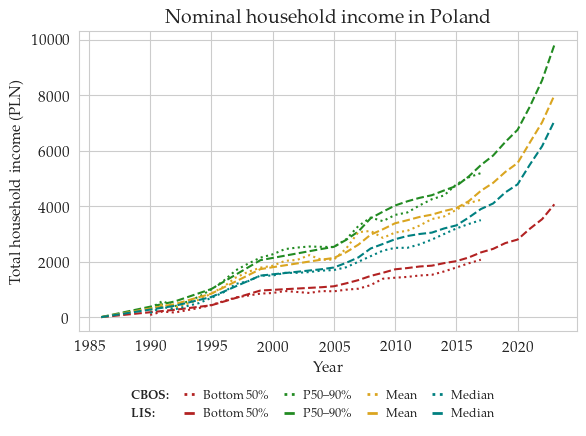

In [8]:

plt.figure()
# Bottom 50%, P50_90, Mean, Median — color by metric, linestyle by dataset
sns.lineplot(data=comp_h, x='year', y='Bottom_50_cbos', color=COLORS_S['Bottom_50'], linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='Bottom_50_lis',  color=COLORS_S['Bottom_50'], linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='P50_90_cbos',    color=COLORS_S['P50_90'],    linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='P50_90_lis',     color=COLORS_S['P50_90'],    linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='mean_cbos',      color=COLORS_S['mean'],      linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='mean_lis',       color=COLORS_S['mean'],      linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='median_cbos',    color=COLORS_S['median'],    linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='median_lis',     color=COLORS_S['median'],    linestyle=LS_LIS)
plt.title("Nominal household income in Poland", fontsize=14)
plt.ylabel("Total household income (PLN)")
plt.xlabel("Year")
_h = [Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], color=COLORS_S['Bottom_50'], lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Bottom_50'], lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['P50_90'],    lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['P50_90'],    lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['mean'],      lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['mean'],      lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['median'],    lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['median'],    lw=2, linestyle=LS_LIS)]
_l = [r'\textbf{CBOS:}', r'\textbf{LIS:}',
      r'Bottom 50\%',    r'Bottom 50\%',
      r'P50--90\%',      r'P50--90\%',
      'Mean',            'Mean',
      'Median',          'Median']
plt.legend(_h, _l, loc='upper center', bbox_to_anchor=(0.45, -0.16),
           ncol=5, frameon=False, handlelength=1.0, handletextpad=0.5, columnspacing=1.2, fontsize=9)
plt.savefig(PLOT_ROOT / "CBOS_vs_LIS_nominal_income_bottom.png", bbox_inches='tight')
plt.show()


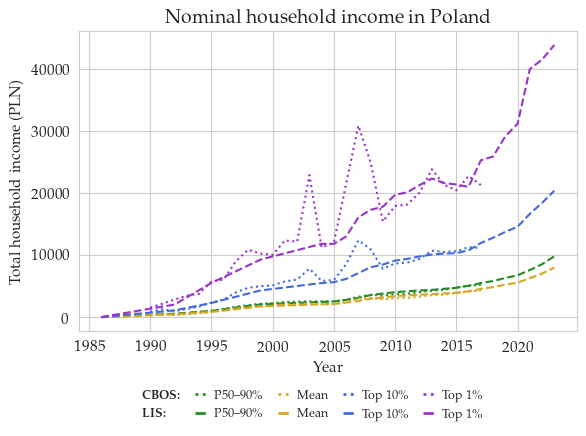

In [9]:

plt.figure()
# P50_90, Mean, Top_10, Top_1 — color by metric, linestyle by dataset
sns.lineplot(data=comp_h, x='year', y='P50_90_cbos', color=COLORS_S['P50_90'], linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='P50_90_lis',  color=COLORS_S['P50_90'], linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='mean_cbos',   color=COLORS_S['mean'],   linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='mean_lis',    color=COLORS_S['mean'],   linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='Top_10_cbos', color=COLORS_S['Top_10'], linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='Top_10_lis',  color=COLORS_S['Top_10'], linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='Top_1_cbos',  color=COLORS_S['Top_1'],  linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='Top_1_lis',   color=COLORS_S['Top_1'],  linestyle=LS_LIS)
plt.title("Nominal household income in Poland", fontsize=14)
plt.ylabel("Total household income (PLN)")
plt.xlabel("Year")
_h = [Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], color=COLORS_S['P50_90'], lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['P50_90'], lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['mean'],   lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['mean'],   lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['Top_10'], lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Top_10'], lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['Top_1'],  lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Top_1'],  lw=2, linestyle=LS_LIS)]
_l = [r'\textbf{CBOS:}', r'\textbf{LIS:}',
      r'P50--90\%',       r'P50--90\%',
      'Mean',             'Mean',
      r'Top 10\%',        r'Top 10\%',
      r'Top 1\%',         r'Top 1\%']
plt.legend(_h, _l, loc='upper center', bbox_to_anchor=(0.45, -0.16),
           ncol=5, frameon=False, handlelength=1.0, handletextpad=0.5, columnspacing=1.2, fontsize=9)
plt.savefig(PLOT_ROOT / "CBOS_vs_LIS_nominal_income_top.png")
plt.show()


In [10]:
# Derived income columns
cbos["H_total_income"] = cbos["income_hh_t_imputed"]    # Total household income
cbos["P_income"] = cbos["income_p_imputed"]             # Per-person income

# Initialize analyzers ----------------------------------------------------------

DEFL = None
DEFL_M = None
if True:
    DEFL = 'deflator_2023'  # Use 1990 deflator for all analyses for comparability
    DEFL_M = 'deflator_2023_m'  # Use 1990 monthly deflator for all analyses for comparability


# CBOS: person-level income with original survey weight (for LIS comparability)
cbos_p = ia.CBOSAnalyzer(cbos, income_col='P_income',
                         weight_col='weight',
                         deflator_col=DEFL_M)  # Use monthly deflator for person-level income to better reflect timing of income

# CBOS: household-level income with original survey weight
cbos_h = ia.CBOSAnalyzer(cbos, income_col='H_total_income',
                         weight_col='weight',
                         deflator_col=DEFL_M)  # Use monthly deflator for household-level income to better reflect timing of income

# LIS: person-level country data with subgroups
lis_p = ia.LISCountryAnalyzer(lis_country, income_type='pitotalnet',
                               deflator_col=DEFL)

# LIS: household-level country data with subgroups
lis_h = ia.LISCountryAnalyzer(lis_country, income_type='hitotalnet')

print("CBOS (person):", cbos_p.summary())
print("CBOS (household):", cbos_h.summary())
print("LIS (person):", lis_p.summary())
print("LIS (household):", lis_h.summary())

# CBOS: compute from microdata (annual, pooling all months per year)
cbos_p_ts = cbos_p.country_timeseries(freq='annual')
cbos_h_ts = cbos_h.country_timeseries(freq='annual') 

# LIS: read pre-computed aggregate row ('persons' / 'households')
lis_p_ts = lis_p.aggregate_timeseries(metrics=['Bottom_50', 'Top_10', 'Top_1', 'P50_90', 'mean', 'median', 'share_Bottom_50', 'share_Top_10', 'share_Top_1', 'share_P50_90', 'gini'])
lis_h_ts = lis_h.aggregate_timeseries(metrics=['Bottom_50', 'Top_10', 'Top_1', 'P50_90', 'mean', 'median', 'share_Bottom_50', 'share_Top_10', 'share_Top_1', 'share_P50_90', 'gini'])
# Merge for comparison
comp_p = ia.compare_cbos_lis(cbos_p_ts, lis_p_ts,
                             metrics=['Bottom_50', 'Top_10', 'Top_1', 'P50_90', 'mean', 'median', 'share_Bottom_50', 'share_Top_10', 'share_Top_1', 'share_P50_90', 'gini'])
comp_h = ia.compare_cbos_lis(cbos_h_ts, lis_h_ts,
                             metrics=['Bottom_50', 'Top_10', 'Top_1', 'P50_90', 'mean', 'median', 'share_Bottom_50', 'share_Top_10', 'share_Top_1', 'share_P50_90', 'gini'])


CBOS (person): {'n_observations': 355336, 'year_range': (np.int64(1990), np.int64(2017)), 'n_years': 28, 'income_col': 'P_income', 'weight_col': 'weight', 'deflator_col': 'deflator_2023_m', 'income_non_null': np.int64(352371), 'weight_non_null': np.int64(355336)}
CBOS (household): {'n_observations': 355336, 'year_range': (np.int64(1990), np.int64(2017)), 'n_years': 28, 'income_col': 'H_total_income', 'weight_col': 'weight', 'deflator_col': 'deflator_2023_m', 'income_non_null': np.int64(352371), 'weight_non_null': np.int64(355336)}
LIS (person): {'income_type': 'pitotalnet', 'unit': 'p', 'aggregate_row': 'persons', 'n_subgroups': 31, 'year_range': (np.int64(1986), np.int64(2023)), 'n_metrics': 31, 'deflator': 'deflator_2023'}
LIS (household): {'income_type': 'hitotalnet', 'unit': 'h', 'aggregate_row': 'households', 'n_subgroups': 36, 'year_range': (np.int64(1986), np.int64(2023)), 'n_metrics': 31, 'deflator': None}


In [11]:
lis_country

,year,pitotalnet_N_total,pitotalnet_Nw_total,pitotalnet_mean,pitotalnet_median,pitotalnet_p10,pitotalnet_p25,pitotalnet_p75,pitotalnet_p90,pitotalnet_p99,...,hilab_pens_Nw_Top_10,hilab_pens_Nw_Top_1,hilab_pens_share_Bottom_50,hilab_pens_share_P50_90,hilab_pens_share_Top_10,hilab_pens_share_Top_1,deflator_1986,deflator_1990,deflator_2017,deflator_2023
0,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5482.9211,1096.5842,0.2768,0.4961,0.2271,0.0536,0.924028,32.081920,764.697340,1080.294342
1,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,137073.0286,14255.5950,0.2783,0.4931,0.2286,0.0394,0.924028,32.081920,764.697340,1080.294342
2,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,310333.3367,31800.9426,0.3098,0.4748,0.2155,0.0425,0.924028,32.081920,764.697340,1080.294342
3,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,222606.5984,23028.2688,0.3147,0.4804,0.2049,0.0369,0.924028,32.081920,764.697340,1080.294342
4,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,202868.0823,20835.1003,0.2635,0.4974,0.2391,0.0469,0.924028,32.081920,764.697340,1080.294342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1234,2023,6870.0,4.116577e+06,46962.3173,42000.0,0.0,20400.0000,60000.0,90321.2422,216000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000834,0.028965,0.690394,0.975325
1235,2023,24918.0,1.246730e+07,28231.8837,27600.0,0.0,0.0000,42000.0,56400.0000,118800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000834,0.028965,0.690394,0.975325
1236,2023,30644.0,1.638333e+07,29332.5921,30000.0,0.0,2590.0801,42000.0,55440.0000,114000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000834,0.028965,0.690394,0.975325
1237,2023,26748.0,1.494165e+07,39800.7004,38400.0,0.0,14400.0000,54000.0,75949.2031,168000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000834,0.028965,0.690394,0.975325


In [12]:
lis_h.aggregate_timeseries(metrics=['Bottom_50', 'Top_10', 'Top_1', 'P50_90', 'mean', 'median'])

,Bottom_50,Top_10,Top_1,P50_90,mean,median
year,,,,,,
1986,2.228000,9.775783,17.645717,5.199917,4.171717,3.684167
1992,267.478308,1098.443700,2036.934392,567.183233,470.533467,409.833342
1995,430.692175,2285.480475,5521.800958,1017.150200,850.802800,730.215167
1999,961.789892,4304.133908,9264.480342,2056.139325,1733.844050,1500.000000
2004,1081.834758,5499.597292,11815.923850,2460.858158,2075.301758,1730.000000
2005,1115.286583,5638.981475,11805.785283,2537.444808,2136.542883,1792.040042
2006,1220.821625,6163.451633,13000.068075,2788.213050,2342.063750,1959.730025
2007,1337.402842,7102.806225,16081.908742,3092.111775,2615.914167,2156.100100
2008,1488.330583,8039.317650,17294.338967,3566.451475,2974.755833,2477.540042


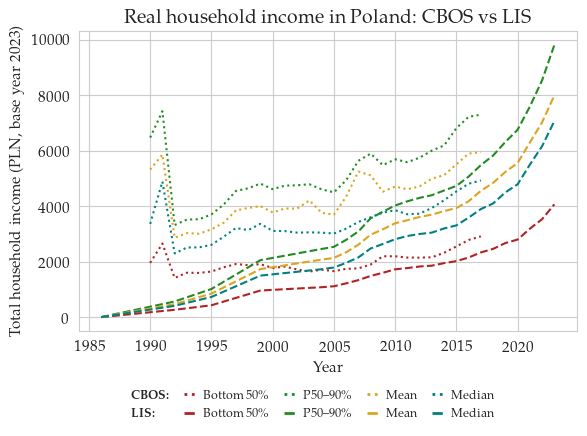

In [13]:

plt.figure()
# Bottom 50%, P50_90, Mean, Median — color by metric, linestyle by dataset
sns.lineplot(data=comp_h, x='year', y='Bottom_50_cbos', color=COLORS_S['Bottom_50'], linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='Bottom_50_lis',  color=COLORS_S['Bottom_50'], linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='P50_90_cbos',    color=COLORS_S['P50_90'],    linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='P50_90_lis',     color=COLORS_S['P50_90'],    linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='mean_cbos',      color=COLORS_S['mean'],      linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='mean_lis',       color=COLORS_S['mean'],      linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='median_cbos',    color=COLORS_S['median'],    linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='median_lis',     color=COLORS_S['median'],    linestyle=LS_LIS)
plt.title("Real household income in Poland: CBOS vs LIS", fontsize=14)
plt.ylabel("Total household income (PLN, base year 2023)")
plt.xlabel("Year")
_h = [Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], color=COLORS_S['Bottom_50'], lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Bottom_50'], lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['P50_90'],    lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['P50_90'],    lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['mean'],      lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['mean'],      lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['median'],    lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['median'],    lw=2, linestyle=LS_LIS)]
_l = [r'\textbf{CBOS:}', r'\textbf{LIS:}',
      r'Bottom 50\%',    r'Bottom 50\%',
      r'P50--90\%',      r'P50--90\%',
      'Mean',            'Mean',
      'Median',          'Median']
plt.legend(_h, _l, loc='upper center', bbox_to_anchor=(0.45, -0.16),
           ncol=5, frameon=False, handlelength=1.0, handletextpad=0.5, columnspacing=1.2, fontsize=9)
plt.savefig(PLOT_ROOT / "CBOS_vs_LIS_defl_income_bottom.png")
plt.show()


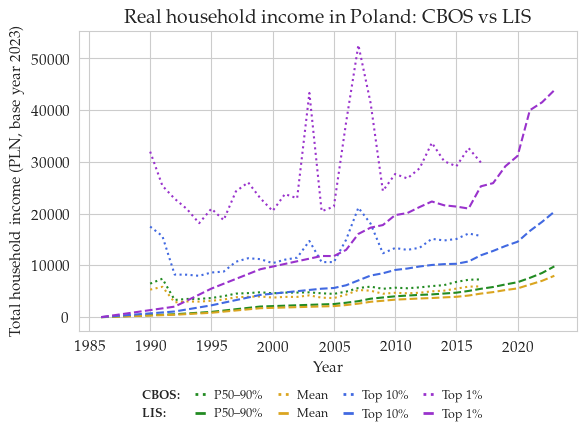

In [14]:

plt.figure()
# P50_90, Mean, Top_10, Top_1 — color by metric, linestyle by dataset
sns.lineplot(data=comp_h, x='year', y='P50_90_cbos', color=COLORS_S['P50_90'], linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='P50_90_lis',  color=COLORS_S['P50_90'], linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='mean_cbos',   color=COLORS_S['mean'],   linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='mean_lis',    color=COLORS_S['mean'],   linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='Top_10_cbos', color=COLORS_S['Top_10'], linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='Top_10_lis',  color=COLORS_S['Top_10'], linestyle=LS_LIS)
sns.lineplot(data=comp_h, x='year', y='Top_1_cbos',  color=COLORS_S['Top_1'],  linestyle=LS_CBOS)
sns.lineplot(data=comp_h, x='year', y='Top_1_lis',   color=COLORS_S['Top_1'],  linestyle=LS_LIS)
plt.title("Real household income in Poland: CBOS vs LIS", fontsize=14)
plt.ylabel("Total household income (PLN, base year 2023)")
plt.xlabel("Year")
_h = [Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], color=COLORS_S['P50_90'], lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['P50_90'], lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['mean'],   lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['mean'],   lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['Top_10'], lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Top_10'], lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['Top_1'],  lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Top_1'],  lw=2, linestyle=LS_LIS)]
_l = [r'\textbf{CBOS:}', r'\textbf{LIS:}',
      r'P50--90\%',       r'P50--90\%',
      'Mean',             'Mean',
      r'Top 10\%',        r'Top 10\%',
      r'Top 1\%',         r'Top 1\%']
plt.legend(_h, _l, loc='upper center', bbox_to_anchor=(0.45, -0.16),
           ncol=5, frameon=False, handlelength=1.0, handletextpad=0.5, columnspacing=1.2, fontsize=9)
plt.savefig(PLOT_ROOT / "CBOS_vs_LIS_defl_income_top.png")
plt.show()


In [15]:
# Derived income columns
cbos["H_total_income"] = cbos["income_hh_t_imputed"]    # Total household income
cbos["P_income"] = cbos["income_p_imputed"]             # Per-person income

# Initialize analyzers ----------------------------------------------------------

DEFL = None
DEFL_M = None
if True:
    DEFL = 'deflator_2023'  # Use 1990 deflator for all analyses for comparability
    DEFL_M = 'deflator_2023_m'  # Use 1990 monthly deflator for all analyses for comparability


# CBOS: person-level income with original survey weight (for LIS comparability)
cbos_p = ia.CBOSAnalyzer(cbos, income_col='P_income',
                         weight_col='weight',
                         deflator_col=DEFL_M)  # Use monthly deflator for person-level income to better reflect timing of income

# CBOS: household-level income with original survey weight
cbos_h = ia.CBOSAnalyzer(cbos, income_col='H_total_income',
                         weight_col='weight',
                         deflator_col=DEFL_M)  # Use monthly deflator for household-level income to better reflect timing of income

# LIS: person-level country data with subgroups
lis_p = ia.LISCountryAnalyzer(lis_country, income_type='pitotalnet',
                               deflator_col=DEFL)

# LIS: household-level country data with subgroups
lis_h = ia.LISCountryAnalyzer(lis_country, income_type='hitotalnet',
                               deflator_col=DEFL)

print("CBOS (person):", cbos_p.summary())
print("CBOS (household):", cbos_h.summary())
print("LIS (person):", lis_p.summary())
print("LIS (household):", lis_h.summary())

# CBOS: compute from microdata (annual, pooling all months per year)
cbos_p_ts = cbos_p.country_timeseries(freq='monthly')
cbos_h_ts = cbos_h.country_timeseries(freq='monthly') 

# LIS: read pre-computed aggregate row ('persons' / 'households')
lis_p_ts = lis_p.aggregate_timeseries(metrics=['Bottom_50', 'Top_10', 'Top_1', 'P50_90', 'mean', 'median', 'share_Bottom_50', 'share_Top_10', 'share_Top_1', 'share_P50_90', 'gini'])
lis_h_ts = lis_h.aggregate_timeseries(metrics=['Bottom_50', 'Top_10', 'Top_1', 'P50_90', 'mean', 'median', 'share_Bottom_50', 'share_Top_10', 'share_Top_1', 'share_P50_90', 'gini'])


CBOS (person): {'n_observations': 355336, 'year_range': (np.int64(1990), np.int64(2017)), 'n_years': 28, 'income_col': 'P_income', 'weight_col': 'weight', 'deflator_col': 'deflator_2023_m', 'income_non_null': np.int64(352371), 'weight_non_null': np.int64(355336)}
CBOS (household): {'n_observations': 355336, 'year_range': (np.int64(1990), np.int64(2017)), 'n_years': 28, 'income_col': 'H_total_income', 'weight_col': 'weight', 'deflator_col': 'deflator_2023_m', 'income_non_null': np.int64(352371), 'weight_non_null': np.int64(355336)}
LIS (person): {'income_type': 'pitotalnet', 'unit': 'p', 'aggregate_row': 'persons', 'n_subgroups': 31, 'year_range': (np.int64(1986), np.int64(2023)), 'n_metrics': 31, 'deflator': 'deflator_2023'}
LIS (household): {'income_type': 'hitotalnet', 'unit': 'h', 'aggregate_row': 'households', 'n_subgroups': 36, 'year_range': (np.int64(1986), np.int64(2023)), 'n_metrics': 31, 'deflator': 'deflator_2023'}


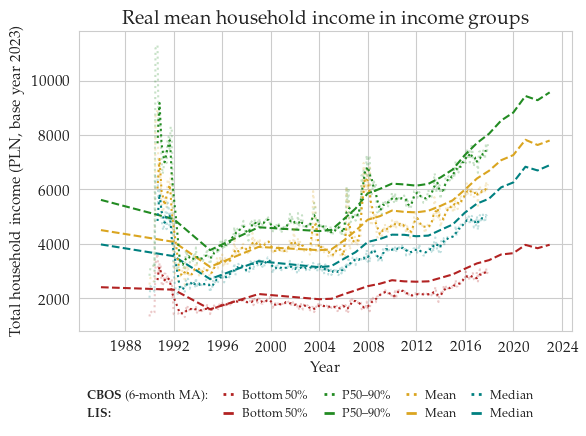

In [16]:

plt.figure()
lis_h_ts.index = pd.to_datetime(lis_h_ts.index, format='%Y')  # Convert LIS index to datetime for better plotting
# Raw CBOS (low alpha), LIS annual, and CBOS 6-month MA — color by metric, linestyle by dataset
sns.lineplot(data=cbos_h_ts, x='date', y='Bottom_50', color=COLORS_S['Bottom_50'], alpha=0.25, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='Bottom_50', color=COLORS_S['Bottom_50'], linestyle=LS_LIS)
sns.lineplot(data=cbos_h_ts, x='date', y='P50_90',    color=COLORS_S['P50_90'],    alpha=0.25, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='P50_90',    color=COLORS_S['P50_90'],    linestyle=LS_LIS)
sns.lineplot(data=cbos_h_ts, x='date', y='mean',      color=COLORS_S['mean'],      alpha=0.25, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='mean',      color=COLORS_S['mean'],      linestyle=LS_LIS)
sns.lineplot(data=cbos_h_ts, x='date', y='median',    color=COLORS_S['median'],    alpha=0.25, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='median',    color=COLORS_S['median'],    linestyle=LS_LIS)
# Rolling averages for CBOS
cbos_h_ts['Bottom_50_MA'] = cbos_h_ts['Bottom_50'].rolling(window=6, center=True).mean()
cbos_h_ts['P50_90_MA']    = cbos_h_ts['P50_90'].rolling(window=6, center=True).mean()
cbos_h_ts['mean_MA']      = cbos_h_ts['mean'].rolling(window=6, center=True).mean()
cbos_h_ts['median_MA']    = cbos_h_ts['median'].rolling(window=6, center=True).mean()
sns.lineplot(data=cbos_h_ts, x='date', y='Bottom_50_MA', color=COLORS_S['Bottom_50'], linestyle=LS_CBOS, lw=1.5)
sns.lineplot(data=cbos_h_ts, x='date', y='P50_90_MA',    color=COLORS_S['P50_90'],    linestyle=LS_CBOS, lw=1.5)
sns.lineplot(data=cbos_h_ts, x='date', y='mean_MA',      color=COLORS_S['mean'],      linestyle=LS_CBOS, lw=1.5)
sns.lineplot(data=cbos_h_ts, x='date', y='median_MA',    color=COLORS_S['median'],    linestyle=LS_CBOS, lw=1.5)
plt.title("Real mean household income in income groups", fontsize=14)
plt.ylabel("Total household income (PLN, base year 2023)")
plt.xlabel("Year")
_h = [Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], color=COLORS_S['Bottom_50'], lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Bottom_50'], lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['P50_90'],    lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['P50_90'],    lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['mean'],      lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['mean'],      lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['median'],    lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['median'],    lw=2, linestyle=LS_LIS)]
_l = [r'\textbf{CBOS} (6-month MA):', r'\textbf{LIS:}',
      r'Bottom 50\%',                  r'Bottom 50\%',
      r'P50--90\%',                    r'P50--90\%',
      'Mean',                          'Mean',
      'Median',                        'Median']
plt.legend(_h, _l, loc='upper center', bbox_to_anchor=(0.45, -0.16),
           ncol=5, frameon=False, handlelength=1.0, handletextpad=0.5, columnspacing=1.2, fontsize=9)
plt.savefig(PLOT_ROOT / "CBOS_vs_LIS_defl_income_bottom_monthly.png")
plt.show()


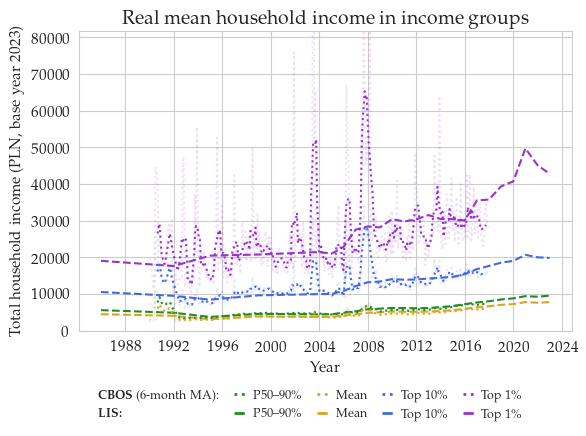

In [17]:

plt.figure()
lis_h_ts.index = pd.to_datetime(lis_h_ts.index, format='%Y')  # Convert LIS index to datetime for better plotting
# Raw CBOS (low alpha), LIS annual, and CBOS 6-month MA — color by metric, linestyle by dataset
sns.lineplot(data=cbos_h_ts, x='date', y='P50_90', color=COLORS_S['P50_90'], alpha=0.15, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='P50_90', color=COLORS_S['P50_90'], linestyle=LS_LIS)
sns.lineplot(data=cbos_h_ts, x='date', y='mean',   color=COLORS_S['mean'],   alpha=0.15, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='mean',   color=COLORS_S['mean'],   linestyle=LS_LIS)
sns.lineplot(data=cbos_h_ts, x='date', y='Top_10', color=COLORS_S['Top_10'], alpha=0.15, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='Top_10', color=COLORS_S['Top_10'], linestyle=LS_LIS)
sns.lineplot(data=cbos_h_ts, x='date', y='Top_1',  color=COLORS_S['Top_1'],  alpha=0.15, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='Top_1',  color=COLORS_S['Top_1'],  linestyle=LS_LIS)
# Rolling averages for CBOS
cbos_h_ts['P50_90_MA'] = cbos_h_ts['P50_90'].rolling(window=6, center=True).mean()
cbos_h_ts['mean_MA']   = cbos_h_ts['mean'].rolling(window=6, center=True).mean()
cbos_h_ts['Top_10_MA'] = cbos_h_ts['Top_10'].rolling(window=6, center=True).mean()
cbos_h_ts['Top_1_MA']  = cbos_h_ts['Top_1'].rolling(window=6, center=True).mean()
sns.lineplot(data=cbos_h_ts, x='date', y='P50_90_MA', color=COLORS_S['P50_90'], linestyle=LS_CBOS, lw=1.5)
sns.lineplot(data=cbos_h_ts, x='date', y='mean_MA',   color=COLORS_S['mean'],   linestyle=LS_CBOS, lw=1.5)
sns.lineplot(data=cbos_h_ts, x='date', y='Top_10_MA', color=COLORS_S['Top_10'], linestyle=LS_CBOS, lw=1.5)
sns.lineplot(data=cbos_h_ts, x='date', y='Top_1_MA',  color=COLORS_S['Top_1'],  linestyle=LS_CBOS, lw=1.5)
# Cap the y-axis to avoid outliers dominating the plot
max_y = max(cbos_h_ts['P50_90_MA'].max(), cbos_h_ts['mean_MA'].max(), cbos_h_ts['Top_10_MA'].max(), cbos_h_ts['Top_1_MA'].max()) * 1.25
plt.ylim(0, max_y)
plt.title("Real mean household income in income groups", fontsize=14)
plt.ylabel("Total household income (PLN, base year 2023)")
plt.xlabel("Year")
_h = [Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], color=COLORS_S['P50_90'], lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['P50_90'], lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['mean'],   lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['mean'],   lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['Top_10'], lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Top_10'], lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['Top_1'],  lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Top_1'],  lw=2, linestyle=LS_LIS)]
_l = [r'\textbf{CBOS} (6-month MA):', r'\textbf{LIS:}',
      r'P50--90\%',                    r'P50--90\%',
      'Mean',                          'Mean',
      r'Top 10\%',                     r'Top 10\%',
      r'Top 1\%',                      r'Top 1\%']
plt.legend(_h, _l, loc='upper center', bbox_to_anchor=(0.45, -0.16),
           ncol=5, frameon=False, handlelength=1.0, handletextpad=0.5, columnspacing=1.2, fontsize=9)
plt.savefig(PLOT_ROOT / "CBOS_vs_LIS_defl_income_top_monthly.png")
plt.show()


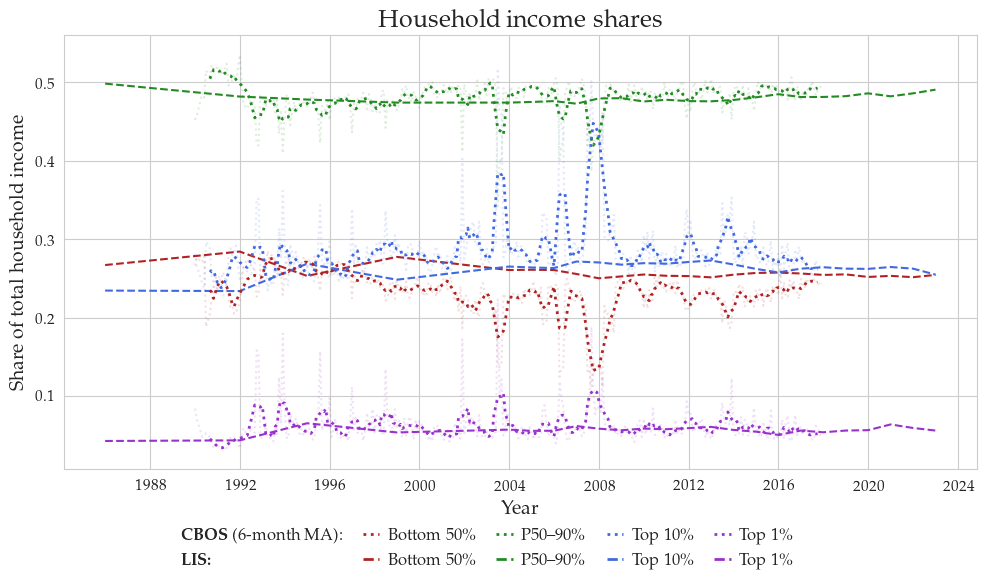

In [18]:

# Now income shares
plt.figure(figsize=(10, 6))
lis_h_ts.index = pd.to_datetime(lis_h_ts.index, format='%Y')
# Raw CBOS (low alpha), LIS annual, and CBOS 6-month MA — color by metric, linestyle by dataset
sns.lineplot(data=cbos_h_ts, x='date', y='share_Bottom_50', color=COLORS_S['Bottom_50'], alpha=0.15, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='share_Bottom_50', color=COLORS_S['Bottom_50'], linestyle=LS_LIS, lw=1.5)
sns.lineplot(data=cbos_h_ts, x='date', y='share_P50_90',    color=COLORS_S['P50_90'],    alpha=0.15, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='share_P50_90',    color=COLORS_S['P50_90'],    linestyle=LS_LIS, lw=1.5)
sns.lineplot(data=cbos_h_ts, x='date', y='share_Top_10',    color=COLORS_S['Top_10'],    alpha=0.15, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='share_Top_10',    color=COLORS_S['Top_10'],    linestyle=LS_LIS, lw=1.5)
sns.lineplot(data=cbos_h_ts, x='date', y='share_Top_1',     color=COLORS_S['Top_1'],     alpha=0.15, linestyle=LS_CBOS)
sns.lineplot(data=lis_h_ts,  x='year', y='share_Top_1',     color=COLORS_S['Top_1'],     linestyle=LS_LIS, lw=1.5)
# Rolling averages for CBOS
cbos_h_ts['share_Bottom_50_MA'] = cbos_h_ts['share_Bottom_50'].rolling(window=6, center=True).mean()
cbos_h_ts['share_P50_90_MA']    = cbos_h_ts['share_P50_90'].rolling(window=6, center=True).mean()
cbos_h_ts['share_Top_10_MA']    = cbos_h_ts['share_Top_10'].rolling(window=6, center=True).mean()
cbos_h_ts['share_Top_1_MA']     = cbos_h_ts['share_Top_1'].rolling(window=6, center=True).mean()
sns.lineplot(data=cbos_h_ts, x='date', y='share_Bottom_50_MA', color=COLORS_S['Bottom_50'], linestyle=LS_CBOS, lw=2)
sns.lineplot(data=cbos_h_ts, x='date', y='share_P50_90_MA',    color=COLORS_S['P50_90'],    linestyle=LS_CBOS, lw=2)
sns.lineplot(data=cbos_h_ts, x='date', y='share_Top_10_MA',    color=COLORS_S['Top_10'],    linestyle=LS_CBOS, lw=2)
sns.lineplot(data=cbos_h_ts, x='date', y='share_Top_1_MA',     color=COLORS_S['Top_1'],     linestyle=LS_CBOS, lw=2)

plt.title("Household income shares", fontsize=18)
plt.ylabel("Share of total household income", fontsize=14)
plt.xlabel("Year", fontsize=14)
_h = [Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], lw=0, color='none'),
      Line2D([0],[0], color=COLORS_S['Bottom_50'], lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Bottom_50'], lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['P50_90'],    lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['P50_90'],    lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['Top_10'],    lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Top_10'],    lw=2, linestyle=LS_LIS),
      Line2D([0],[0], color=COLORS_S['Top_1'],     lw=2, linestyle=LS_CBOS),
      Line2D([0],[0], color=COLORS_S['Top_1'],     lw=2, linestyle=LS_LIS)]
_l = [r'\textbf{CBOS} (6-month MA):', r'\textbf{LIS:}',
      r'Bottom 50\%',                  r'Bottom 50\%',
      r'P50--90\%',                    r'P50--90\%',
      r'Top 10\%',                     r'Top 10\%',
      r'Top 1\%',                      r'Top 1\%']
plt.legend(_h, _l, loc='upper center', bbox_to_anchor=(0.45, -0.1),
           ncol=5, frameon=False, handlelength=1.0, handletextpad=0.5, columnspacing=1.2, fontsize=12)
plt.savefig(PLOT_ROOT / "CBOS_vs_LIS_income_shares_monthly.png")
plt.show()


In [19]:
# Derived income columns
cbos["H_total_income"] = cbos["income_hh_t_imputed"]    # Total household income
cbos["P_income"] = cbos["income_p_imputed"]             # Per-person income

# Initialize analyzers ----------------------------------------------------------

DEFL = None
DEFL_M = None
if True:
    DEFL = 'deflator_2023'  # Use 1990 deflator for all analyses for comparability
    DEFL_M = 'deflator_2023_m'  # Use 1990 monthly deflator for all analyses for comparability


# CBOS: person-level income with original survey weight (for LIS comparability)
cbos_p = ia.CBOSAnalyzer(cbos, income_col='P_income',
                         weight_col='weight',
                         deflator_col=DEFL_M)  # Use monthly deflator for person-level income to better reflect timing of income

# CBOS: household-level income with original survey weight
cbos_h = ia.CBOSAnalyzer(cbos, income_col='H_total_income',
                         weight_col='weight',
                         deflator_col=DEFL_M)  # Use monthly deflator for household-level income to better reflect timing of income

# LIS: person-level country data with subgroups
lis_p = ia.LISCountryAnalyzer(lis_country, income_type='pitotalnet',
                               deflator_col=DEFL)

# LIS: household-level country data with subgroups
lis_h = ia.LISCountryAnalyzer(lis_country, income_type='hitotalnet',
                               deflator_col=DEFL)

print("CBOS (person):", cbos_p.summary())
print("CBOS (household):", cbos_h.summary())
print("LIS (person):", lis_p.summary())
print("LIS (household):", lis_h.summary())

# CBOS: compute from microdata (annual, pooling all months per year)
cbos_p_ts = cbos_p.country_timeseries(freq='annual')
cbos_h_ts = cbos_h.country_timeseries(freq='annual') 

# LIS: read pre-computed aggregate row ('persons' / 'households')
lis_p_ts = lis_p.aggregate_timeseries(metrics=['theil'])
lis_h_ts = lis_h.aggregate_timeseries(metrics=['theil'])
# Merge for comparison
comp_p = ia.compare_cbos_lis(cbos_p_ts, lis_p_ts,
                             metrics=['theil'])
comp_h = ia.compare_cbos_lis(cbos_h_ts, lis_h_ts,
                             metrics=['theil'])


CBOS (person): {'n_observations': 355336, 'year_range': (np.int64(1990), np.int64(2017)), 'n_years': 28, 'income_col': 'P_income', 'weight_col': 'weight', 'deflator_col': 'deflator_2023_m', 'income_non_null': np.int64(352371), 'weight_non_null': np.int64(355336)}
CBOS (household): {'n_observations': 355336, 'year_range': (np.int64(1990), np.int64(2017)), 'n_years': 28, 'income_col': 'H_total_income', 'weight_col': 'weight', 'deflator_col': 'deflator_2023_m', 'income_non_null': np.int64(352371), 'weight_non_null': np.int64(355336)}
LIS (person): {'income_type': 'pitotalnet', 'unit': 'p', 'aggregate_row': 'persons', 'n_subgroups': 31, 'year_range': (np.int64(1986), np.int64(2023)), 'n_metrics': 31, 'deflator': 'deflator_2023'}
LIS (household): {'income_type': 'hitotalnet', 'unit': 'h', 'aggregate_row': 'households', 'n_subgroups': 36, 'year_range': (np.int64(1986), np.int64(2023)), 'n_metrics': 31, 'deflator': 'deflator_2023'}


In [20]:
# ── Cell: Locality-size subgroup Theil — CBOS vs LIS ────────────────────────

# CBOS: within-group Theil per locality class (each group computed independently)
cbos_cs_ts = cbos_h.country_subgroup_timeseries('cs_L', weight_col='weight')

# CBOS: between/within decomposition (requires microdata → available via regional_theil_timeseries)
cbos_cs_between = cbos_h.regional_theil_timeseries('cs_L')

# LIS: within-group Theil per popclass
lis_cs_ts = lis_h.subgroup_timeseries(category='popclass')

# LIS: between-group Theil (manual — no microdata available)
# T_B = Σ_g  s_g · ln(μ_g / μ)   where  s_g = Nw_g·μ_g / Σ(Nw_g·μ_g)
_lis_between_rows = []
for year in sorted(lis_cs_ts['year'].unique()):
    sub = lis_cs_ts[lis_cs_ts['year'] == year].dropna(subset=['mean', 'Nw_total'])
    nw, mu_g = sub['Nw_total'].values, sub['mean'].values
    pos = (nw > 0) & (mu_g > 0)
    if pos.sum() < 2:
        continue
    mu   = (nw[pos] * mu_g[pos]).sum() / nw[pos].sum()
    s_g  = (nw[pos] * mu_g[pos]) / (nw[pos] * mu_g[pos]).sum()
    _lis_between_rows.append({'year': year,
                               'between': float((s_g * np.log(mu_g[pos] / mu)).sum())})
lis_cs_between = pd.DataFrame(_lis_between_rows)

print("CBOS between-group Theil sample:")
print(cbos_cs_between[['year', 'between', 'within', 'between_pct']].head())
print("\nLIS between-group Theil sample:")
print(lis_cs_between.head())


CBOS between-group Theil sample:
   year   between    within  between_pct
0  1990  0.000258  0.368934     0.069973
1  1991  0.000897  0.250489     0.356771
2  1992  0.005225  0.315896     1.627066
3  1993  0.007827  0.250322     3.032021
4  1994  0.010723  0.209536     4.868295

LIS between-group Theil sample:
   year   between
0  1992  0.000511
1  1995  0.006246
2  1999  0.004862
3  2004  0.006703
4  2005  0.005104


In [21]:
# Labels map for cs_L subgroups
labels_map_cs_L = {'wieś': 'rural',
                   'do 20 tys. mieszkańców': 'city <20k',
                   '20-100 tys. mieszkańców': 'city 20-100k',
                   '100-500 tys. mieszkańców': 'city 100-500k',
                   "powyżej 500 tys. mieszkańców": 'city >500k'}

# Labels map for popclass subgroups
labels_map_popclass = {'h_popclass_wies': 'rural',
                       'h_popclass_do_20k': 'city <20k',
                       'h_popclass_20k_100k': 'city 20-100k',
                       'h_popclass_100k_500k': 'city 100-500k',
                       'h_popclass_pow_500k': 'city >500k'}

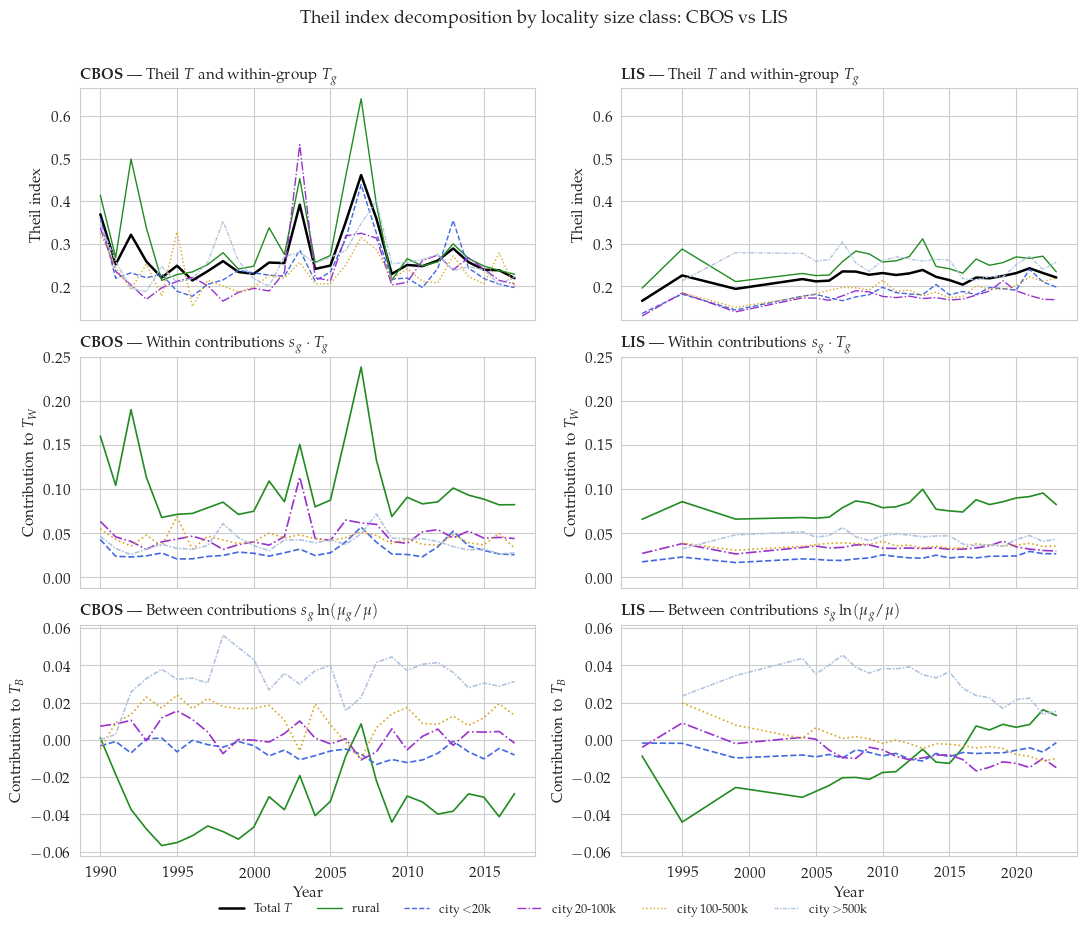

In [23]:
# ── CBOS: per-class Theil contributions over time ────────────────────────────
cbos_contrib_cs = cbos_h.theil_contribution_timeseries('cs_L')

# ── LIS: per-class Theil contributions (manual — no microdata) ──────────────
_lis_contrib_rows = []
for year in sorted(lis_cs_ts['year'].unique()):
    sub = lis_cs_ts[lis_cs_ts['year'] == year].dropna(subset=['mean', 'Nw_total', 'theil'])
    nw, mu_g, t_g = sub['Nw_total'].values, sub['mean'].values, sub['theil'].values
    sg_names = sub['subgroup'].values
    pos = (nw > 0) & (mu_g > 0)
    if pos.sum() < 2:
        continue
    mu = (nw[pos] * mu_g[pos]).sum() / nw[pos].sum()
    s_g = (nw[pos] * mu_g[pos]) / (nw[pos] * mu_g[pos]).sum()
    for j, idx in enumerate(np.where(pos)[0]):
        _lis_contrib_rows.append({
            'year': year,
            'group': sg_names[idx],
            'income_share': s_g[j],
            'between_contribution': float(s_g[j] * np.log(mu_g[idx] / mu)),
            'within_contribution': float(s_g[j] * t_g[idx]),
        })
lis_contrib_cs = pd.DataFrame(_lis_contrib_rows)

# Reconstruct LIS total Theil per year
lis_total_by_year = (lis_contrib_cs.groupby('year')
                     [['between_contribution', 'within_contribution']].sum()
                     .reset_index())
lis_total_by_year['total_theil'] = (lis_total_by_year['between_contribution']
                                    + lis_total_by_year['within_contribution'])

# ── Ordered subgroup keys & labels ──────────────────────────────────────────
SG_CBOS_KEYS = list(labels_map_cs_L.keys())
SG_LIS_KEYS  = list(labels_map_popclass.keys())
SG_LABELS    = ['rural', r'city $<$20k', 'city 20-100k', 'city 100-500k', r'city $>$500k']
SG_COLORS    = ['forestgreen', 'royalblue', 'darkorchid', 'goldenrod', 'lightsteelblue']
SG_STYLES    = ['-', '--', '-.', ':', (0,(3,1,1,1))]

# ── Figure: 3 rows × 2 columns (CBOS | LIS) ────────────────────────────────
#   Row 0: Total Theil T + within-group T_g  (line plots)
#   Row 1: Within contributions s_g·T_g      (line plots, always ≥ 0)
#   Row 2: Between contributions s_g·ln(μ_g/μ) (line plots, can be negative)
fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex='col')
fig.subplots_adjust(hspace=0.35, wspace=0.28)

def _plot_lines(ax, contrib, sg_keys, sg_key_col, col, labels, palette, title, ylabel):
    """Plot one contribution component as lines per locality class."""
    for i, (key, lbl) in enumerate(zip(sg_keys, labels)):
        d = contrib[contrib[sg_key_col] == key].sort_values('year')
        ax.plot(d['year'], d[col], color=palette[i], ls=SG_STYLES[i], lw=1.2, label=lbl)
    ax.axhline(0, color='grey', lw=0.5, zorder=0)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, loc='left')

# ── Row 0: Total Theil + within-group Theil ─────────────────────────────────
for col_idx, (total_yr, total_T, sg_data, sg_keys, title_ds) in enumerate([
    (cbos_cs_between['year'], cbos_cs_between['total_theil'],
     cbos_cs_ts, SG_CBOS_KEYS, 'CBOS'),
    (lis_total_by_year['year'], lis_total_by_year['total_theil'],
     lis_cs_ts, SG_LIS_KEYS, 'LIS'),
]):
    ax = axes[0, col_idx]
    ax.plot(total_yr, total_T, color='black', lw=1.8, label='Total $T$')
    for i, (key, lbl) in enumerate(zip(sg_keys, SG_LABELS)):
        d = sg_data[sg_data['subgroup'] == key].sort_values('year')
        ax.plot(d['year'], d['theil'], color=SG_COLORS[i], ls=SG_STYLES[i], lw=1, label=lbl)
    ax.set_ylabel('Theil index')
    ax.set_title(rf'\textbf{{{title_ds}}} --- Theil $T$ and within-group $T_g$',
                 fontsize=11, loc='left')

# ── Row 1: Within contributions  s_g · T_g ─────────────────────────────────
_plot_lines(axes[1, 0], cbos_contrib_cs, SG_CBOS_KEYS, 'group',
            'within_contribution', SG_LABELS, SG_COLORS,
            r'\textbf{CBOS} --- Within contributions $s_g \cdot T_g$',
            'Contribution to $T_W$')
_plot_lines(axes[1, 1], lis_contrib_cs, SG_LIS_KEYS, 'group',
            'within_contribution', SG_LABELS, SG_COLORS,
            r'\textbf{LIS} --- Within contributions $s_g \cdot T_g$',
            'Contribution to $T_W$')

# ── Row 2: Between contributions  s_g · ln(μ_g/μ) ──────────────────────────
_plot_lines(axes[2, 0], cbos_contrib_cs, SG_CBOS_KEYS, 'group',
            'between_contribution', SG_LABELS, SG_COLORS,
            r'\textbf{CBOS} --- Between contributions $s_g \ln(\mu_g/\mu)$',
            'Contribution to $T_B$')
_plot_lines(axes[2, 1], lis_contrib_cs, SG_LIS_KEYS, 'group',
            'between_contribution', SG_LABELS, SG_COLORS,
            r'\textbf{LIS} --- Between contributions $s_g \ln(\mu_g/\mu)$',
            'Contribution to $T_B$')
axes[2, 0].set_xlabel('Year')
axes[2, 1].set_xlabel('Year')

# ── Shared y-limits per row for comparability ────────────────────────────────
for row in range(3):
    ylo = min(axes[row, 0].get_ylim()[0], axes[row, 1].get_ylim()[0])
    yhi = max(axes[row, 0].get_ylim()[1], axes[row, 1].get_ylim()[1])
    axes[row, 0].set_ylim(ylo, yhi)
    axes[row, 1].set_ylim(ylo, yhi)

# ── Shared legend at bottom ─────────────────────────────────────────────────
h0, l0 = axes[0, 0].get_legend_handles_labels()
fig.legend(h0, l0, loc='lower center', ncol=6, frameon=False,
           bbox_to_anchor=(0.5, -0.01), fontsize=9)

fig.suptitle('Theil index decomposition by locality size class: CBOS vs LIS',
             fontsize=13, y=1.01)
plt.savefig(PLOT_ROOT / "CBOS_vs_LIS_theil_decomposition_by_locality.png",
            bbox_inches='tight', dpi = 300)
plt.show()

**Interpretation.**
Both data sources tell a consistent story about the spatial structure of income inequality in Poland.

- **Within-group inequality** (colored lines) is highest in the largest cities — reflecting the wide income dispersion that accompanies urban labour-market stratification. Rural areas and small towns consistently show lower within-group Theil values, indicative of more compressed income distributions.
- **Between-group inequality** (firebrick dashed line) captures how much of total income dispersion is explained by differences in *average* income across locality-size classes. In both CBOS and LIS, the between-group component is small relative to the within-group values, suggesting that **where you live accounts for only a modest share of overall inequality** — most dispersion occurs *within* each locality class rather than *across* them.
- Both sources show a broadly similar **time trend**: within-group inequality rose during the early transition (1990s), moderated in the 2000s, and remained elevated through 2017. The between-group component is relatively stable over time, implying that the urban–rural income gap has not systematically widened or narrowed as a share of total dispersion.
- The close agreement between CBOS (survey microdata) and LIS (harmonised pre-computed statistics) across all locality classes lends confidence to both measurement approaches.
